## Time-Series ananysis
To manage the high imbalance in time series dataset, different standard classifier models were tested on the base dataset and different rolling time serries of the same data, using different time windows: 2hrs, 16 hrs, 24 hrs, 48 hrs

### Conclusion:
The time transformations have not improved the performance

In general, the original data performs well, which indicates, there is not need to implement rolling time transformations

### Model Performance:
GradientBoost has the best overall performance and balance of metrics
RandomForest and AdaBoost are also considerably performing well
DecissionTree, IsolatiionForest and BernoulliNB are uderperforming and not considered for furhter assessment

### Potential hidden issues:
Data leakage is not an option as the test, train dataset is "cut" by the explicit time and the orignal test dataset was used for the rolling data also
!! Evaluate precission recall curves -> test if the dataset is recognising the failure or classifies everything as positive
Try different models like LSTM and autoencoders

In [ ]:
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit

from src.time_series_transformations import calculate_rolling_stats
from src.visualisations import time_window_rolling_stats
from src.standard_models import classifier_model_test
from src.data_transformations import test_train_split

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
df = pd.read_parquet("data/clean/sensor_clean.pqt")
df = df.drop(columns=['day_of_week','month','hour'])

In [4]:
# Define the time windows (in minutes)
time_windows = [120, 960, 1440, 2880]

# Define the metric columns
metric_columns = [
    'sensor_00',
    'sensor_04',
    'sensor_10',
    'sensor_06',
    'sensor_11',
    'sensor_07',
    'sensor_02',
]

# Transform "Recovey" status into error term
df['machine_status_code'] = df['machine_status_code'].replace({2 : 1})

# Create an error dataset for reference check
df_error = df[df['machine_status_code'] == 1]

In [5]:
df_rolling = calculate_rolling_stats(df,time_windows,metric_columns)

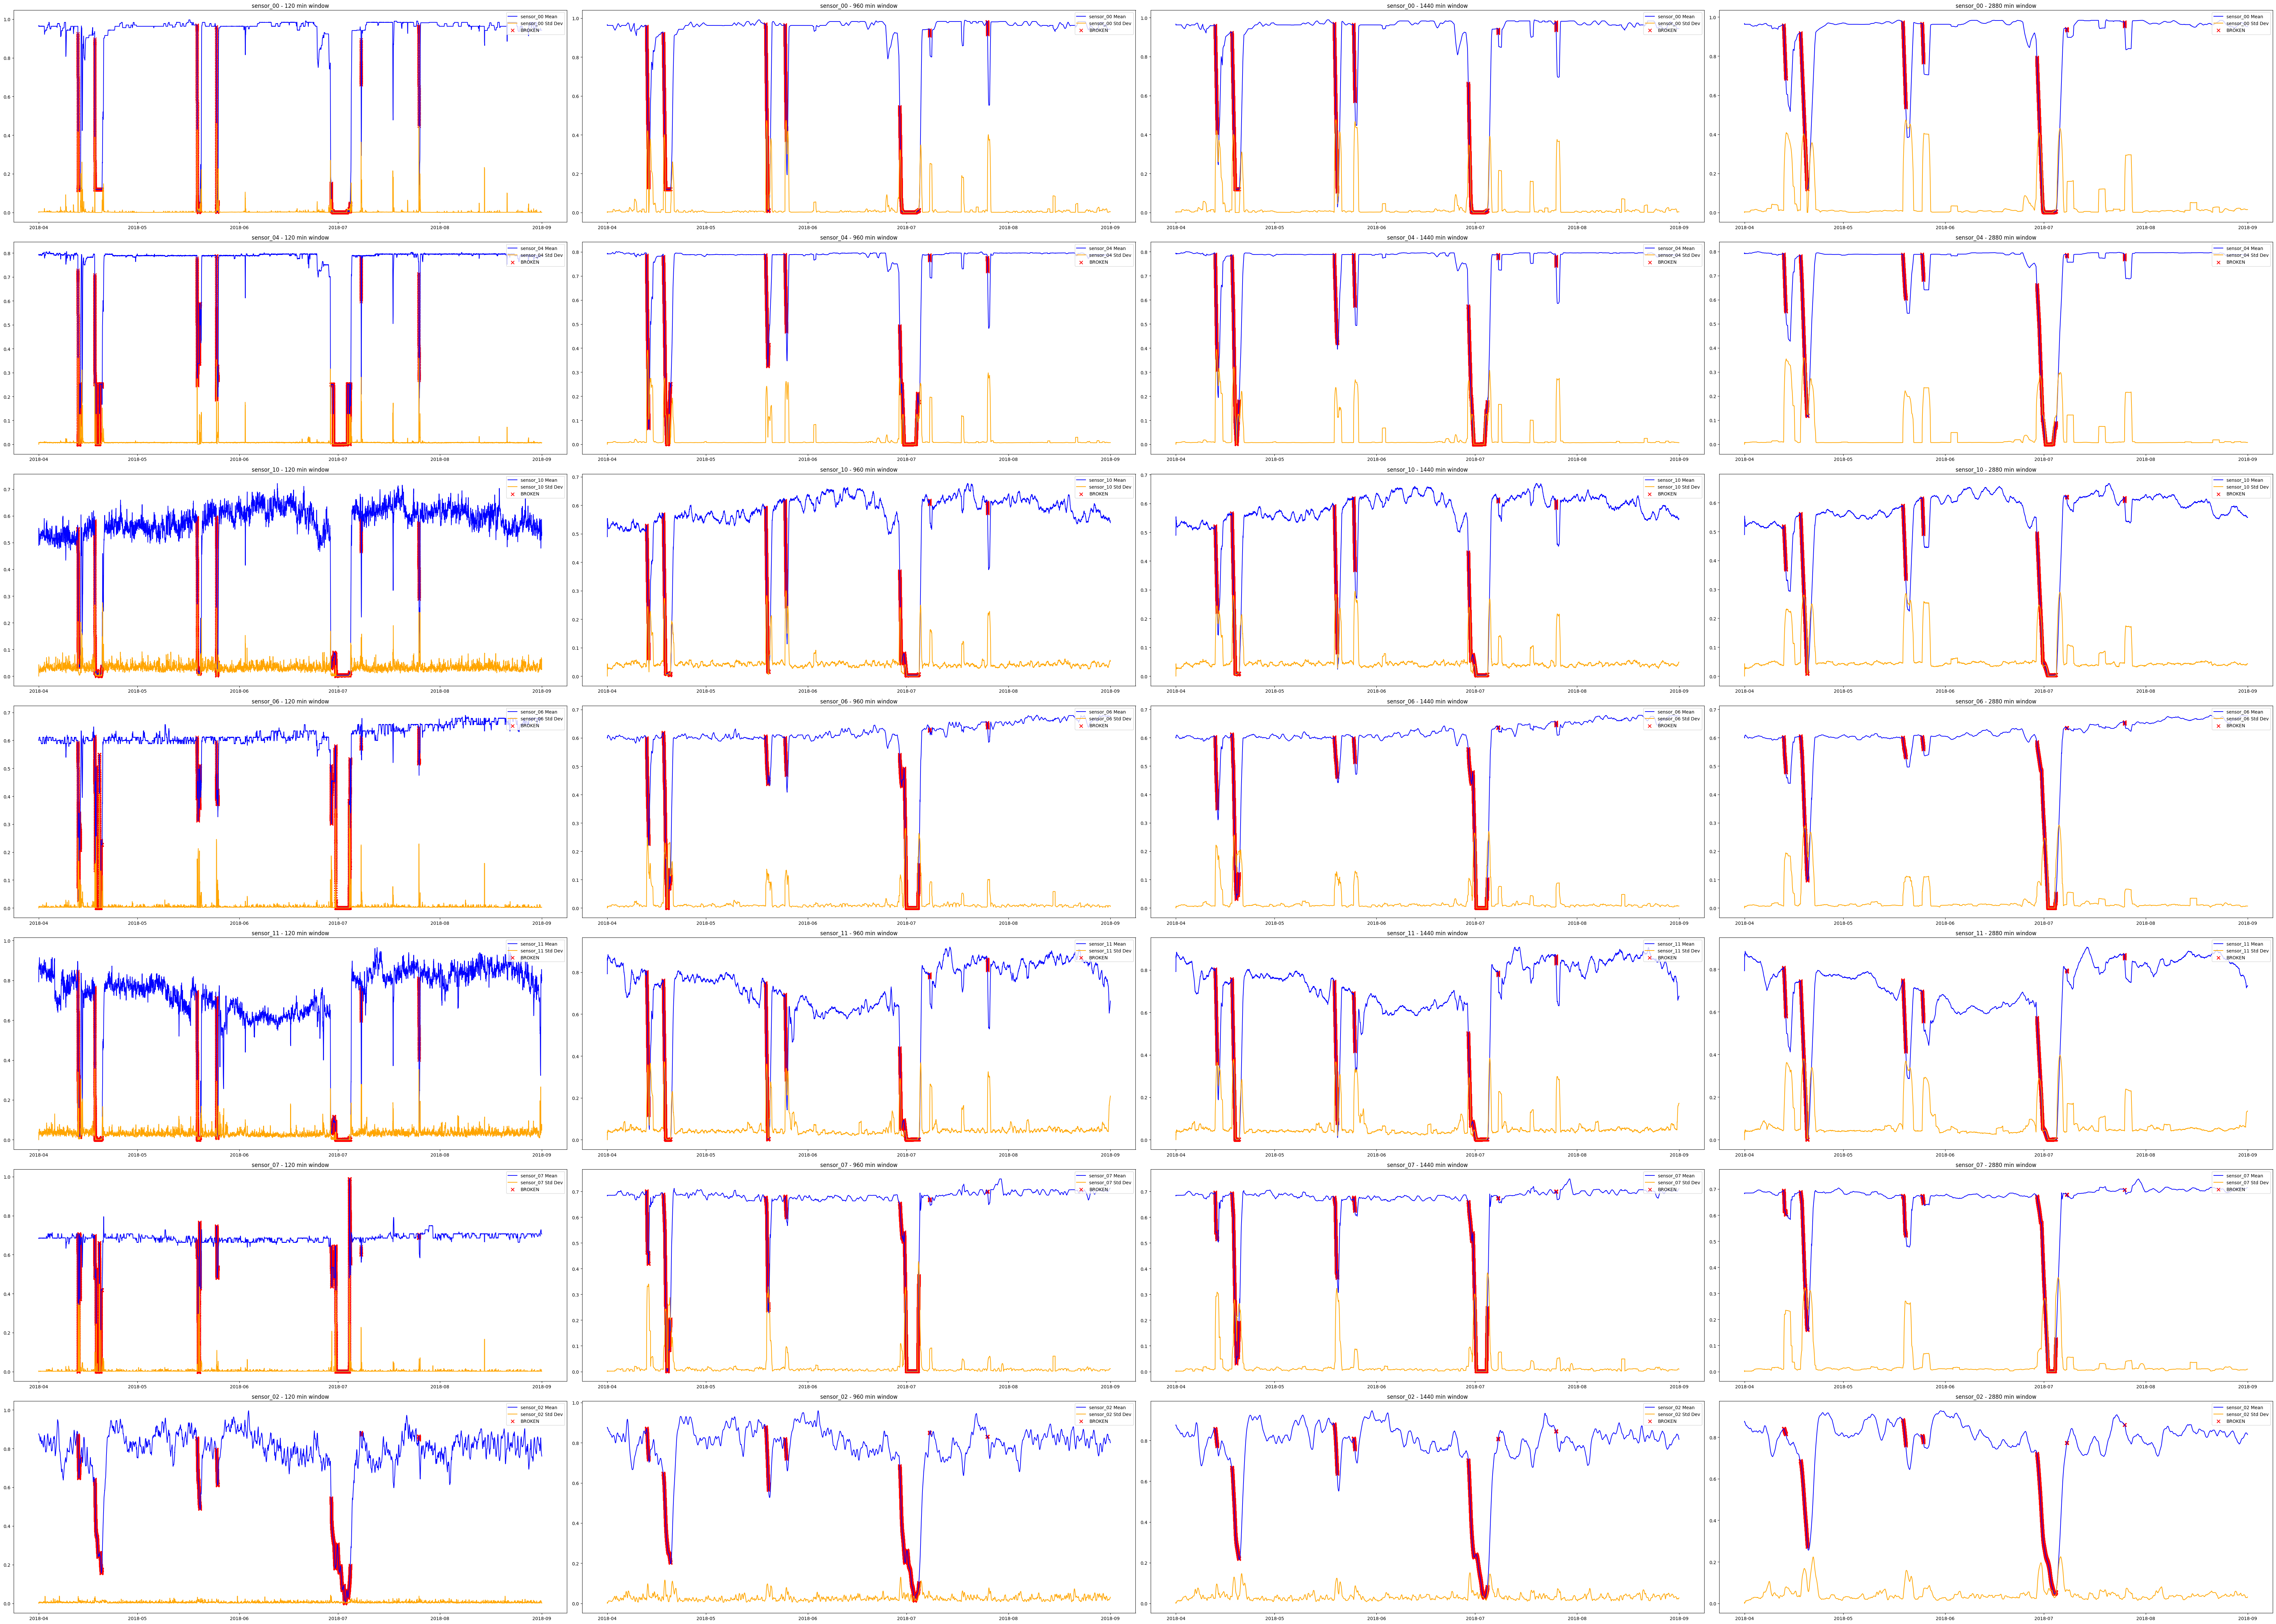

In [6]:
time_window_rolling_stats(df_rolling,df_error,metric_columns,time_windows)

In [7]:
split_time = '2018-06-01'

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


=== CONFUSION MATRICES ===
GradientBoost Confusion Matrix: TN: 123886, FP: 85, FN: 45, TP: 8464
RandomForest Confusion Matrix: TN: 123768, FP: 203, FN: 34, TP: 8475
ExtraTrees Confusion Matrix: TN: 123610, FP: 361, FN: 28, TP: 8481
AdaBoost Confusion Matrix: TN: 123607, FP: 364, FN: 31, TP: 8478
LogisticRegression Confusion Matrix: TN: 123433, FP: 538, FN: 48, TP: 8461
SVC Confusion Matrix: TN: 123390, FP: 581, FN: 25, TP: 8484
KNeighbors Confusion Matrix: TN: 123385, FP: 586, FN: 30, TP: 8479
SGD Confusion Matrix: TN: 123391, FP: 580, FN: 50, TP: 8459
GaussianNB Confusion Matrix: TN: 122775, FP: 1196, FN: 7, TP: 8502
One-Class SVM Confusion Matrix: TN: 121197, FP: 2774, FN: 1541, TP: 6968
DecisionTree Confusion Matrix: TN: 123731, FP: 240, FN: 5322, TP: 3187
Isolation Forest Confusion Matrix: TN: 123573, FP: 398, FN: 7438, TP: 1071
BernoulliNB Confusion Matrix: TN: 123871, FP: 100, FN: 7583, TP: 926


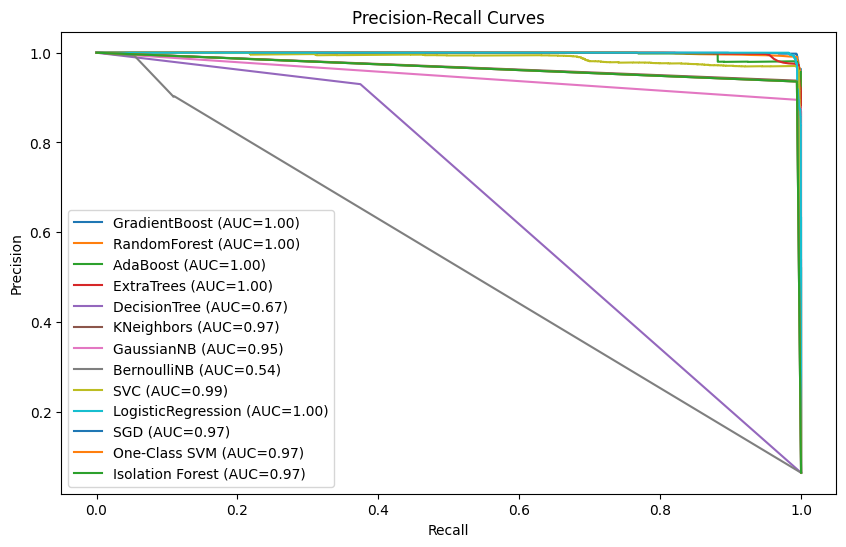

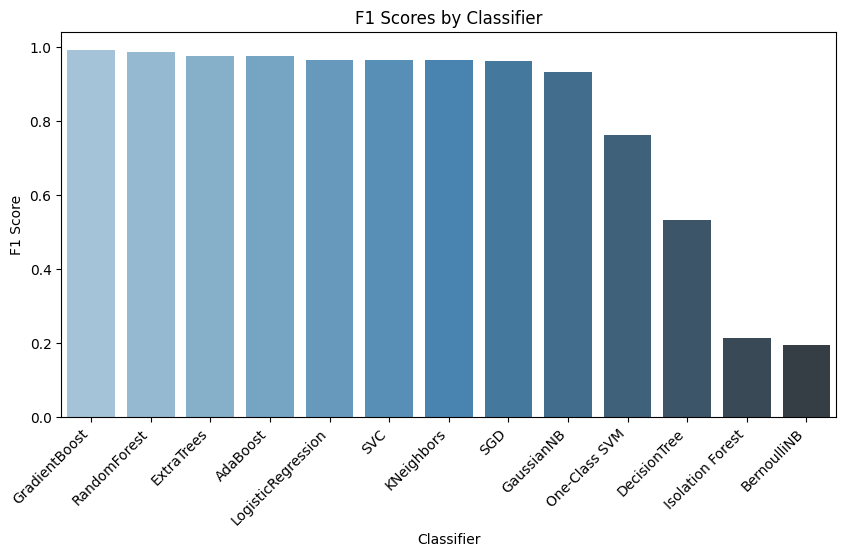

,Accuracy,Precision,Recall,F1,AUC-PR
GradientBoost,0.999019,0.990057,0.994711,0.992379,0.999613
RandomForest,0.998211,0.976608,0.996004,0.986211,0.998884
ExtraTrees,0.997064,0.959172,0.996709,0.977581,0.998701
AdaBoost,0.997018,0.958833,0.996357,0.977235,0.997249
LogisticRegression,0.995577,0.940216,0.994359,0.96653,0.999191
SVC,0.995426,0.935907,0.997062,0.965517,0.988504
KNeighbors,0.99535,0.935356,0.996474,0.964948,0.967518
SGD,0.995245,0.935834,0.994124,0.964098,0.965167
GaussianNB,0.990919,0.876676,0.999177,0.933927,0.94711
One-Class SVM,0.967429,0.715254,0.818898,0.763575,0.965167


In [8]:
X_train, X_test, y_train, y_test = test_train_split(df, split_time)

classifier_model_test(X_train, X_test, y_train, y_test)

In [9]:
df_rolling_960_mean = df_rolling[
    [
    'timestamp',
    'sensor_00_960_mean',
    'sensor_04_960_mean',
    'sensor_10_960_mean',
    'sensor_06_960_mean',
    'sensor_11_960_mean',
    'sensor_07_960_mean',
    'sensor_02_960_mean',
    'machine_status_code'
    ]
]

df_rolling_960_mean = df_rolling_960_mean.rename(columns={
                                'sensor_00_960_mean':'sensor_00',
                                'sensor_04_960_mean':'sensor_04',
                                'sensor_10_960_mean':'sensor_10',
                                'sensor_06_960_mean':'sensor_06',
                                'sensor_11_960_mean':'sensor_11',
                                'sensor_07_960_mean':'sensor_07',
                                'sensor_02_960_mean':'sensor_02',
                                    }
                           )

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


=== CONFUSION MATRICES ===
Isolation Forest Confusion Matrix: TN: 123766, FP: 205, FN: 989, TP: 7520
GaussianNB Confusion Matrix: TN: 122512, FP: 1459, FN: 2, TP: 8507
LogisticRegression Confusion Matrix: TN: 122160, FP: 1811, FN: 492, TP: 8017
SGD Confusion Matrix: TN: 123440, FP: 531, FN: 1792, TP: 6717
KNeighbors Confusion Matrix: TN: 122272, FP: 1699, FN: 1722, TP: 6787
ExtraTrees Confusion Matrix: TN: 121430, FP: 2541, FN: 2513, TP: 5996
SVC Confusion Matrix: TN: 120713, FP: 3258, FN: 2556, TP: 5953
GradientBoost Confusion Matrix: TN: 119016, FP: 4955, FN: 2470, TP: 6039
AdaBoost Confusion Matrix: TN: 117887, FP: 6084, FN: 2024, TP: 6485
RandomForest Confusion Matrix: TN: 113616, FP: 10355, FN: 2413, TP: 6096
DecisionTree Confusion Matrix: TN: 97055, FP: 26916, FN: 2140, TP: 6369
One-Class SVM Confusion Matrix: TN: 74104, FP: 49867, FN: 20, TP: 8489
BernoulliNB Confusion Matrix: TN: 123970, FP: 1, FN: 8268, TP: 241


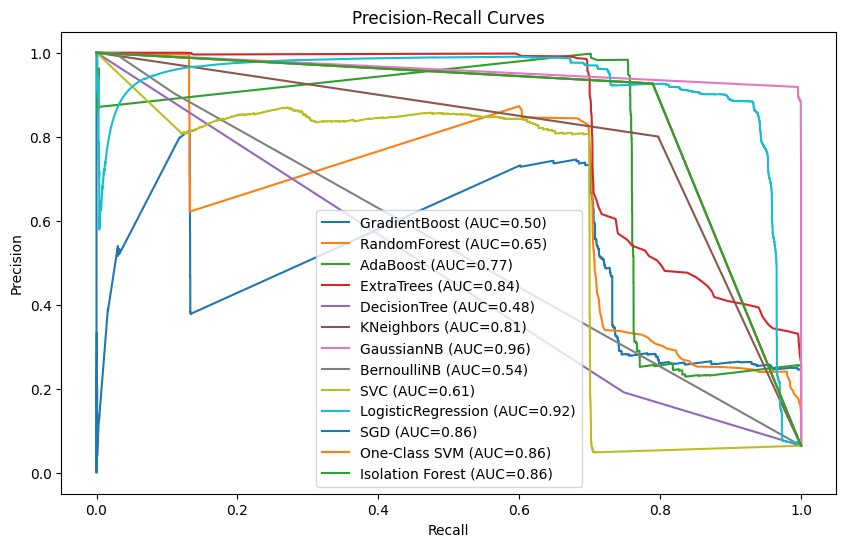

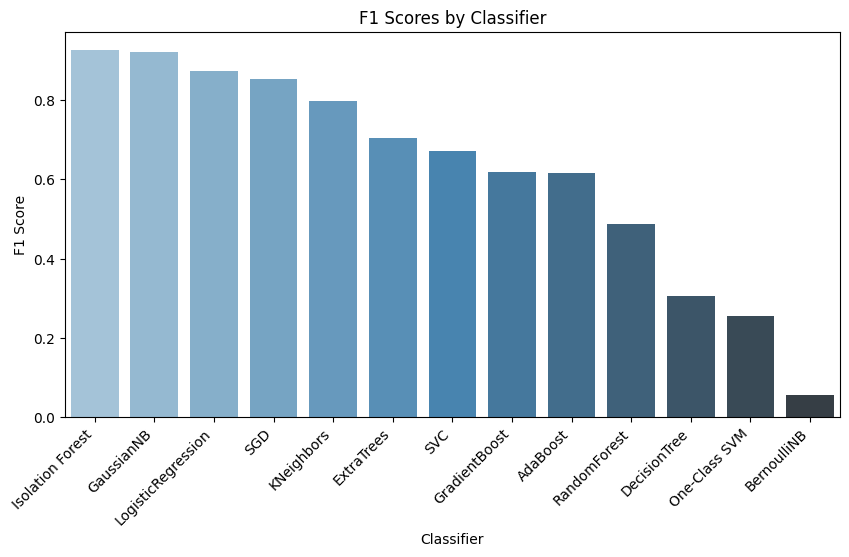

,Accuracy,Precision,Recall,F1,AUC-PR
Isolation Forest,0.990987,0.973463,0.88377,0.926451,0.864832
GaussianNB,0.988972,0.853602,0.999765,0.92092,0.958902
LogisticRegression,0.982616,0.815731,0.942179,0.874407,0.919081
SGD,0.982465,0.926738,0.789399,0.852573,0.864832
KNeighbors,0.974177,0.799788,0.797626,0.798706,0.805264
ExtraTrees,0.961851,0.702354,0.704666,0.703508,0.837412
SVC,0.956114,0.646292,0.699612,0.671896,0.613516
GradientBoost,0.943954,0.5493,0.709719,0.619289,0.500751
AdaBoost,0.938798,0.515952,0.762134,0.615334,0.772409
RandomForest,0.903623,0.370555,0.716418,0.488462,0.651777


In [10]:
X_train_960, X_test_960, y_train_960, y_test_960 = test_train_split(df_rolling_960_mean, split_time)
classifier_model_test(X_train_960, X_test, y_train_960, y_test)

In [11]:
df_rolling_3200_mean = df_rolling[
    [
    'timestamp',
    'sensor_00_2880_mean',
    'sensor_04_2880_mean',
    'sensor_10_2880_mean',
    'sensor_06_2880_mean',
    'sensor_11_2880_mean',
    'sensor_07_2880_mean',
    'sensor_02_2880_mean',
    'machine_status_code'
    ]
]

df_rolling_3200_mean = df_rolling_3200_mean.rename(columns={
                                                            'sensor_00_2880_mean':'sensor_00',
                                                            'sensor_04_2880_mean':'sensor_04',
                                                            'sensor_10_2880_mean':'sensor_10',
                                                            'sensor_06_2880_mean':'sensor_06',
                                                            'sensor_11_2880_mean':'sensor_11',
                                                            'sensor_07_2880_mean':'sensor_07',
                                                            'sensor_02_2880_mean':'sensor_02'
                                                            }
                                                    )

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


=== CONFUSION MATRICES ===
GaussianNB Confusion Matrix: TN: 122350, FP: 1621, FN: 2, TP: 8507
Isolation Forest Confusion Matrix: TN: 123872, FP: 99, FN: 2163, TP: 6346
SGD Confusion Matrix: TN: 123923, FP: 48, FN: 2522, TP: 5987
LogisticRegression Confusion Matrix: TN: 99508, FP: 24463, FN: 1148, TP: 7361
One-Class SVM Confusion Matrix: TN: 54590, FP: 69381, FN: 0, TP: 8509
AdaBoost Confusion Matrix: TN: 121773, FP: 2198, FN: 7675, TP: 834
ExtraTrees Confusion Matrix: TN: 121757, FP: 2214, FN: 8060, TP: 449
BernoulliNB Confusion Matrix: TN: 123970, FP: 1, FN: 8268, TP: 241
DecisionTree Confusion Matrix: TN: 89970, FP: 34001, FN: 7401, TP: 1108
RandomForest Confusion Matrix: TN: 109382, FP: 14589, FN: 7969, TP: 540
GradientBoost Confusion Matrix: TN: 59035, FP: 64936, FN: 7942, TP: 567
KNeighbors Confusion Matrix: TN: 119499, FP: 4472, FN: 8415, TP: 94
SVC Confusion Matrix: TN: 117712, FP: 6259, FN: 8485, TP: 24


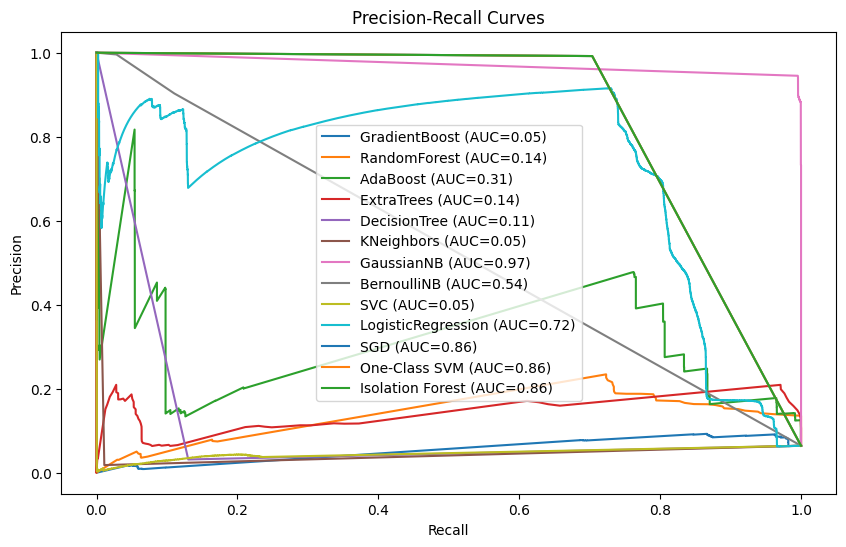

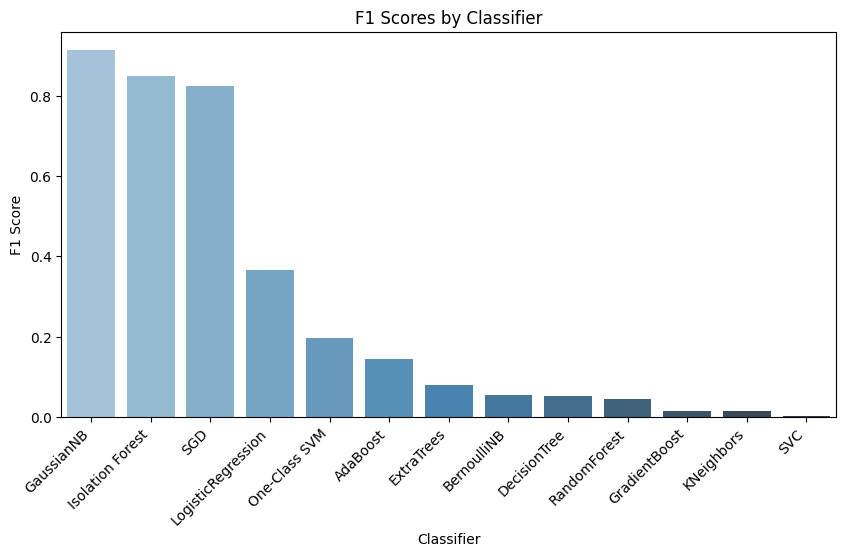

,Accuracy,Precision,Recall,F1,AUC-PR
GaussianNB,0.987749,0.839949,0.999765,0.912915,0.972144
Isolation Forest,0.982926,0.984639,0.745799,0.848736,0.857346
SGD,0.980601,0.992046,0.703608,0.823295,0.857346
LogisticRegression,0.80668,0.231303,0.865084,0.365011,0.721309
One-Class SVM,0.476291,0.109244,1.0,0.19697,0.857346
AdaBoost,0.925476,0.275066,0.098014,0.144528,0.308227
ExtraTrees,0.922449,0.168607,0.052768,0.08038,0.144462
BernoulliNB,0.937583,0.995868,0.028323,0.055079,0.536438
DecisionTree,0.687485,0.031559,0.130215,0.050805,0.108819
RandomForest,0.829725,0.035693,0.063462,0.045689,0.138607


In [12]:
X_train_3200_mean, X_test_3200_mean, y_train_3200_mean, y_test_3200_mean = test_train_split(df_rolling_3200_mean, split_time)
classifier_model_test(X_train_3200_mean, X_test, y_train_3200_mean, y_test)